In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn import metrics
import matplotlib.pyplot as plt
import shap

In [2]:
data = pd.read_csv('data/data_DFT.csv')
y = pd.DataFrame(data['Yield'], columns=['Yield'])
X = data.drop(columns=['PC_ID', 'Alc_ID', 'Yield', 'PC_SMILES', 'Alc_SMILES'])
print(X.head())
print('==========(Result)==========')

r2_score = []
rmse_score = []
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=i)
    param = {"min_samples_leaf": [2, 3, 5], "max_depth": [4, 6], "l2_regularization": [0, 0.1, 1]}
    reg = GridSearchCV(HistGradientBoostingRegressor(random_state=0, max_leaf_nodes=5, max_bins=30),
                       param_grid=param, cv=5, n_jobs=12)
    reg.fit(X_train, y_train['Yield'])
    best = reg.best_estimator_
    y_pred1 = best.predict(X_train)
    y_pred2 = best.predict(X_test)
    r2 = metrics.r2_score(y_test, y_pred2)
    rmse = metrics.root_mean_squared_error(y_test, y_pred2)
    print(f'Run{i} R2 (test): {r2:.2f}, RMSE (test): {rmse:.2f}')
    r2_score.append(r2)
    rmse_score.append(rmse)

    PC_HOMO   PC_LUMO   PC_S1  PC_T1_a  Alc_HOMO  Alc_LUMO     Alc_BDE
0 -9.223168 -0.588574  3.7691    2.606 -8.938541  0.123538  110.283966
1 -9.223168 -0.588574  3.7691    2.606 -8.906977  1.054154  110.158466
2 -9.223168 -0.588574  3.7691    2.606 -8.360308  0.548846  110.164741
3 -9.223168 -0.588574  3.7691    2.606 -8.668336  1.062317  110.089441
4 -9.223168 -0.588574  3.7691    2.606 -8.231872  1.047351  110.409466
==========(Result)==========
Run0 R2 (test): 0.70, RMSE (test): 14.81
Run1 R2 (test): 0.73, RMSE (test): 10.91
Run2 R2 (test): 0.83, RMSE (test): 7.72
Run3 R2 (test): 0.83, RMSE (test): 11.00
Run4 R2 (test): 0.90, RMSE (test): 7.91
Run5 R2 (test): 0.84, RMSE (test): 8.48
Run6 R2 (test): 0.81, RMSE (test): 8.61
Run7 R2 (test): 0.70, RMSE (test): 11.32
Run8 R2 (test): 0.76, RMSE (test): 10.96
Run9 R2 (test): 0.79, RMSE (test): 9.01


0.8954533235915358


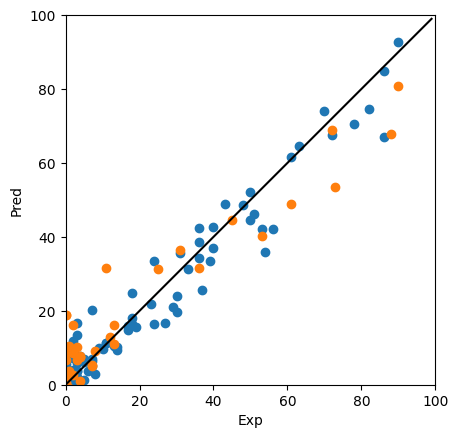

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=4)
param = {"min_samples_leaf": [2, 3, 5], "max_depth": [4, 6], "l2_regularization": [0, 0.1, 1]}
reg = GridSearchCV(HistGradientBoostingRegressor(random_state=0, max_leaf_nodes=5, max_bins=30), param_grid=param, cv=5, n_jobs=12)
reg.fit(X_train, y_train['Yield'])
best = reg.best_estimator_
y_pred1 = best.predict(X_train)
y_pred2 = best.predict(X_test)
print(metrics.r2_score(y_test, y_pred2))

fig = plt.figure()
ax = fig.add_subplot(111)
plt.plot(range(0,100), range(0,100), c='black')
plt.scatter(y_train, y_pred1)
plt.scatter(y_test, y_pred2)
plt.xlim(0, 100)
plt.ylim(0, 100)
ax.set_aspect('equal', adjustable='box')
plt.xlabel('Exp')
plt.ylabel('Pred')

fig.savefig('SHAP/result.pdf')

In [4]:
explainer = shap.TreeExplainer(best)
shap_values = explainer(X)

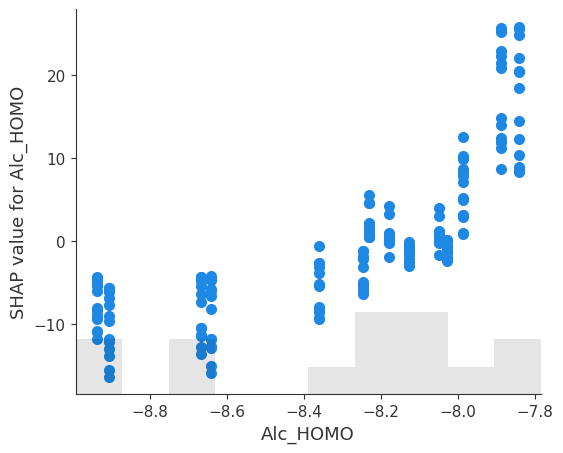

In [5]:
target = 'Alc_HOMO'
shap.plots.scatter(shap_values[:, target], dot_size=64, show=False)
plt.ylabel(f'SHAP value for {target}')
plt.savefig(f'SHAP/scatter_{target}.pdf')
plt.show()

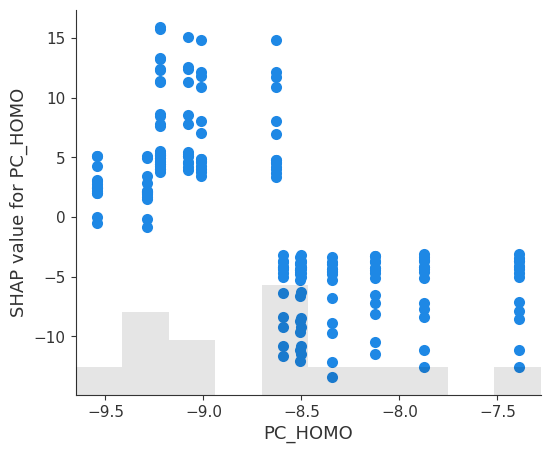

In [6]:
target = 'PC_HOMO'
shap.plots.scatter(shap_values[:, target], dot_size=64, show=False)
plt.ylabel(f'SHAP value for {target}')
plt.savefig(f'SHAP/scatter_{target}.pdf')
plt.show()

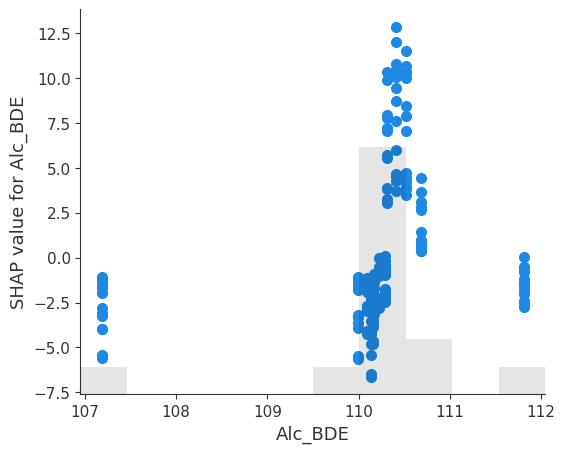

In [7]:
target = 'Alc_BDE'
shap.plots.scatter(shap_values[:, target], dot_size=64, show=False)
plt.ylabel(f'SHAP value for {target}')
plt.savefig(f'SHAP/scatter_{target}.pdf')
plt.show()

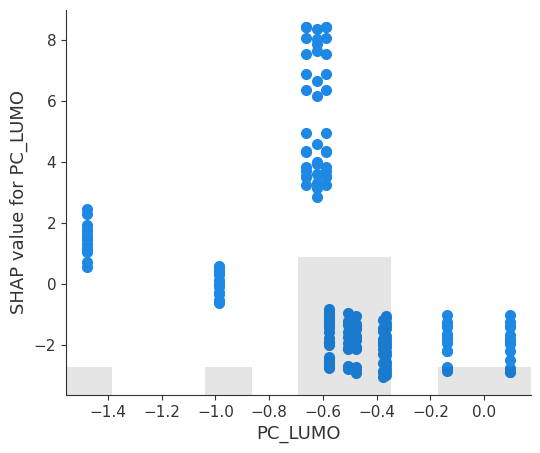

In [8]:
target = 'PC_LUMO'
shap.plots.scatter(shap_values[:, target], dot_size=64, show=False)
plt.ylabel(f'SHAP value for {target}')
plt.savefig(f'SHAP/scatter_{target}.pdf')
plt.show()

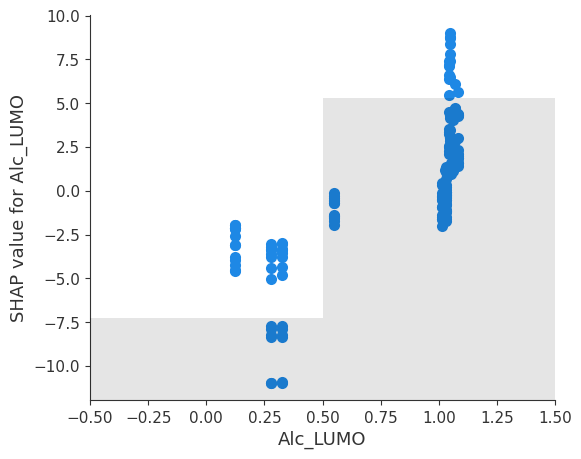

In [9]:
target = 'Alc_LUMO'
shap.plots.scatter(shap_values[:, target], dot_size=64, show=False)
plt.ylabel(f'SHAP value for {target}')
plt.savefig(f'SHAP/scatter_{target}.pdf')
plt.show()

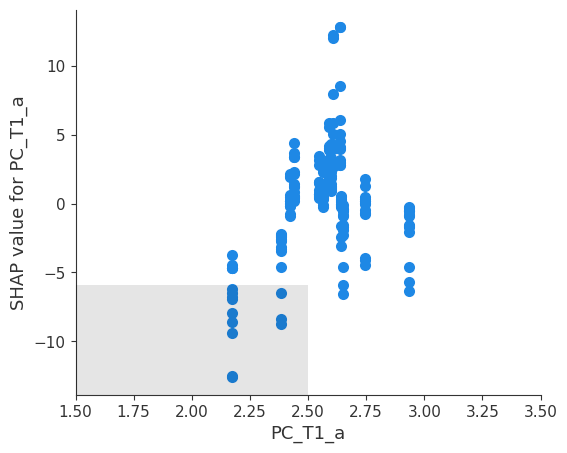

In [10]:
target = 'PC_T1_a'
shap.plots.scatter(shap_values[:, target], dot_size=64, show=False)
plt.ylabel(f'SHAP value for {target}')
plt.savefig(f'SHAP/scatter_{target}.pdf')
plt.show()

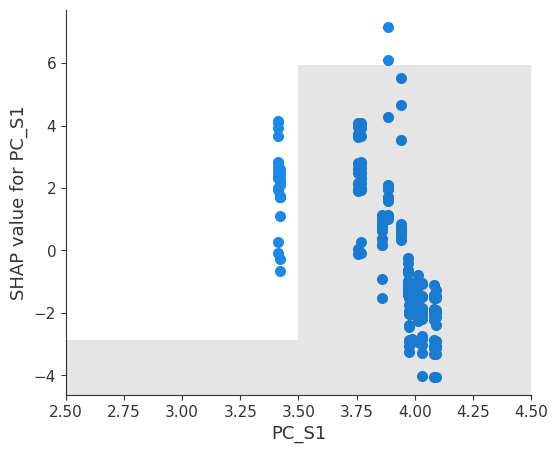

In [11]:
target = 'PC_S1'
shap.plots.scatter(shap_values[:, target], dot_size=64, show=False)
plt.ylabel(f'SHAP value for {target}')
plt.savefig(f'SHAP/scatter_{target}.pdf')
plt.show()